# R 统计代码测试

用 r-lab kernel 测试基础统计功能：描述性统计、正态分布抽样、t 检验、线性回归、相关性。

In [1]:
# 1. 环境信息与描述性统计
cat("R 版本:", R.version.string, "\n\n")

set.seed(42)
x <- c(23, 45, 12, 67, 34, 89, 21, 56, 78, 43)

cat("样本:", x, "\n")
cat("均值:", mean(x), "\n")
cat("中位数:", median(x), "\n")
cat("标准差:", round(sd(x), 3), "\n")
cat("方差:", round(var(x), 3), "\n")
cat("极差:", range(x), "\n\n")

summary(x)

R 版本: R version 4.5.3 (2026-03-11 ucrt) 

样本: 23 45 12 67 34 89 21 56 78 43 
均值: 46.8 
中位数: 44 
标准差: 25.542 
方差: 652.4 
极差: 12 89 



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  12.00   25.75   44.00   46.80   64.25   89.00 

In [3]:
# 2. 正态分布抽样 + 单样本/双样本 t 检验
set.seed(123)
group_a <- rnorm(30, mean = 50, sd = 10)   # A 组
group_b <- rnorm(30, mean = 55, sd = 10)   # B 组

cat("A 组均值:", round(mean(group_a), 2), " B 组均值:", round(mean(group_b), 2), "\n\n")

# 双样本 t 检验：两组均值是否有显著差异
t_res <- t.test(group_a, group_b)
print(t_res)

cat("\np 值 =", round(t_res$p.value, 4),
    ifelse(t_res$p.value < 0.05, " -> 差异显著", " -> 差异不显著"), "\n")

A 组均值: 49.53  B 组均值: 56.78 


	Welch Two Sample t-test

data:  group_a and group_b
t = -3.0841, df = 56.559, p-value = 0.003156
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -11.965426  -2.543416
sample estimates:
mean of x mean of y 
 49.52896  56.78338 


p 值 = 0.0032  -> 差异显著 


In [4]:
# 3. 线性回归 + 相关性
set.seed(7)
n <- 50
height <- rnorm(n, mean = 170, sd = 8)          # 身高 cm
weight <- 0.9 * height - 90 + rnorm(n, 0, 5)     # 体重 kg（与身高线性相关 + 噪声）

# 相关系数
cat("Pearson 相关系数:", round(cor(height, weight), 3), "\n\n")

# 线性回归 weight ~ height
model <- lm(weight ~ height)
print(summary(model))

cat("\n回归方程: weight =", round(coef(model)[1], 2), "+",
    round(coef(model)[2], 2), "* height\n")

Pearson 相关系数: 0.834 


Call:
lm(formula = weight ~ height)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.2948 -2.8140  0.1432  2.8539 11.6877 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -80.10756   13.84515  -5.786 5.31e-07 ***
height        0.84358    0.08045  10.486 5.24e-14 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.547 on 48 degrees of freedom
Multiple R-squared:  0.6961,	Adjusted R-squared:  0.6898 
F-statistic:   110 on 1 and 48 DF,  p-value: 5.24e-14


回归方程: weight = -80.11 + 0.84 * height


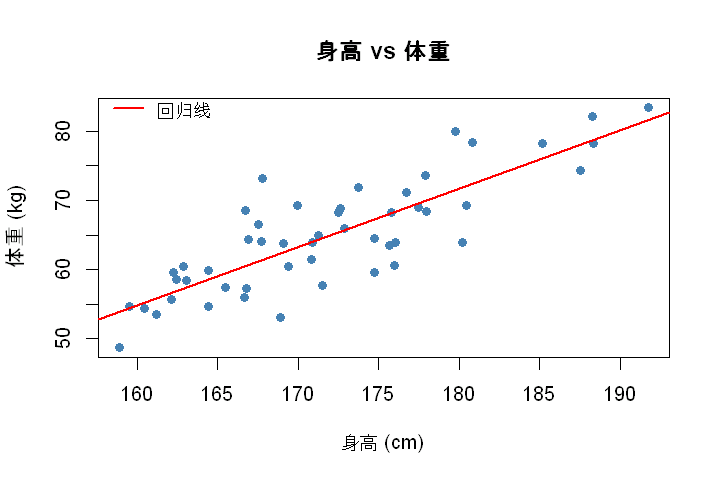

In [5]:
# 4. 可视化：散点图 + 回归线
options(repr.plot.width = 6, repr.plot.height = 4)
plot(height, weight,
     main = "身高 vs 体重", xlab = "身高 (cm)", ylab = "体重 (kg)",
     pch = 19, col = "steelblue")
abline(model, col = "red", lwd = 2)
legend("topleft", legend = "回归线", col = "red", lwd = 2, bty = "n")